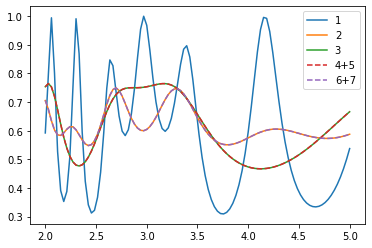

In [94]:
# Here is a test adding an incoherent layer of zero thickness to a stack.
# Since phase information is thrown away inside the stack, coherent 
# connection is lost between layers on either side of it.
# Therefore the 
import numpy as np
import matplotlib.pyplot as plt
import tmm
deg = np.pi/180
#==============================================================================================
# Inputs
#==============================================================================================
th      = 0 * deg
pol     = 's'
nw      = 100
wls = np.linspace(2,5,nw)

n1_list = [  1   , 2.2 ,  3  , 2.2 ,  3  ,   1  ]
d1_list = [np.inf, 1.0 , 1.0 , 1.0 , 1.0 , np.inf]
c1_list = [ 'i'  , 'c' , 'c' , 'c' , 'c' ,  'i' ]

n2_list = [  1   , 2.2 ,  3  , 2.2 ,  3  ,  3  ,   1  ]
d2_list = [np.inf, 1.0 , 1.0 , 1.0 , 0.0 , 1.0 , np.inf]
c2_list = [ 'i'  , 'c' , 'c' , 'c' , 'i' , 'c' ,  'i' ]

n3_list = [  1   , 2.2 ,  3  , 2.2 , 2.2 ,  3  ,   1  ]
d3_list = [np.inf, 1.0 , 1.0 , 1.0 , 0.0 , 1.0 , np.inf]
c3_list = [ 'i'  , 'c' , 'c' , 'c' , 'i' , 'c' ,  'i' ]


n4_list = [  1   , 2.2 ,  3  , 2.2 ,  2.2  ]
d4_list = [np.inf, 1.0 , 1.0 , 1.0 , np.inf]
c4_list = [ 'i'  , 'c' , 'c' , 'c' , 'i'  ]


n5_list = [ 2.2  ,   3  ,   1   ]
d5_list = [np.inf,  1.0 , np.inf]
c5_list = [ 'i'  ,  'c' ,  'i'  ]


n6_list = [  1   , 2.2 ,  3  , 2.2 ,   3   ]
d6_list = [np.inf, 1.0 , 1.0 , 1.0 , np.inf]
c6_list = [ 'i'  , 'c' , 'c' , 'c' ,  'i'  ]


n7_list = [  3   ,   3  ,   1   ]
d7_list = [np.inf,  1.0 , np.inf]
c7_list = [ 'i'  ,  'c' ,  'i'  ]

#==============================================================================================
# Functions
#==============================================================================================
def eps(x,A,x0,eb):
    return eb - A * x0 / (x + 1j * x0) 


def calc_TRA(d_list, n_list, c_list, wls, th, pol):
    nw      = len(wls)
    R,T = [] , []
    for kw in range(0,nw):
        tmp = tmm.tmm_core.inc_tmm(pol, n_list, d_list, c_list, th, wls[kw])
        R.append(tmp['R']); T.append(tmp['T'])
        

    R,T = np.array(R) , np.array(T); A = 1 - R - T
    return T , R , A


def calc_FoM(wls,T,E):
    return np.trapz (T,wls)**2 / np.trapz(E,wls) / np.trapz(wls/wls , wls)


def layer_positions(d_list):
    xlay  = np.cumsum(d_list[1:-1])
    del_x = (xlay[1]-xlay[0])
    xlay  = np.insert(xlay,0,0); xlay = np.append(xlay, xlay[-1]+del_x)
    return xlay - xlay[-1]/2


#==============================================================================================
# Calculations
#==============================================================================================
T1 , R1 , E1 = calc_TRA(d1_list, n1_list, c1_list, wls, th, pol)
T2 , R2 , E2 = calc_TRA(d2_list, n2_list, c2_list, wls, th, pol)
T3 , R3 , E3 = calc_TRA(d3_list, n3_list, c3_list, wls, th, pol)
T4 , R4 , E4 = calc_TRA(d4_list, n4_list, c4_list, wls, th, pol)
T5 , R5 , E5 = calc_TRA(d5_list, n5_list, c5_list, wls, th, pol)
T6 , R6 , E6 = calc_TRA(d6_list, n6_list, c6_list, wls, th, pol)
T7 , R7 , E7 = calc_TRA(d7_list, n7_list, c7_list, wls, th, pol)
plt.plot(wls , T1)
plt.plot(wls , T2)
plt.plot(wls , T3)
plt.plot(wls , T4*T5 / (1-R4*R5) , '--')
plt.plot(wls , T6*T7 / (1-R6*R7) , '--')
plt.legend(['1' , '2' , '3' , '4+5' , '6+7'])